# **6.3 填充和步幅**

根据[6.2](<6.2 图像卷积.ipynb>)的内容，不难发现：
1. 输出形状必然缩小，即部分信息必然丢失。这在需要更全面的信息时很不利。
2. 信息丢失速度也可以调整。信息冗余时可以根据需求对其进行调整。

于是，针对上面两个情况，可以补充一些卷积核性质。



## 6.3.1 填充

对于信息丢失，我们可以对输入进行一些临时的补充。可以理解为，在边缘位置，$x$受影响的形状应该会发生变化，即变相的在边缘对卷积核的形状进行调整。

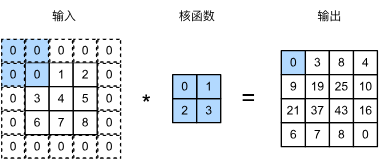](https://zh.d2l.ai/_images/conv-pad.svg)

根据需要（输出形状），对输入进行补充，“增大形状”。
$$
(n_h-k_h+p_h+1)\times(n_w-k_w+p_w+1)
$$
然后根据需要，调整$p_h$核$p_w$即可，通常取$p_h = k_h +1$和$p_w = k_w + 1$。

显然，$p_h , p_w$多为偶数，故卷积核形状多选为基数长度，以实现维度保持。

下面是一个例子。

In [1]:
import torch
from torch import nn


# 为了方便起见，我们定义了一个计算卷积层的函数。
# 此函数初始化卷积层权重，并对输入和输出提高和缩减相应的维数
def comp_conv2d(conv2d, X):
    # 这里的（1，1）表示批量大小和通道数都是1
    X = X.reshape((1, 1) + X.shape)
    Y = conv2d(X)
    # 省略前两个维度：批量大小和通道
    return Y.reshape(Y.shape[2:])

# 请注意，这里每边都填充了1行或1列，因此总共添加了2行或2列
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1)
X = torch.rand(size=(8, 8))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

长不等于宽时调整`padding`形状即可

In [2]:
conv2d = nn.Conv2d(1, 1, kernel_size=(5, 3), padding=(2, 1))
comp_conv2d(conv2d, X).shape

torch.Size([8, 8])

## 6.3.2. 步幅

即一次滑动多格。

![alt text](https://zh.d2l.ai/_images/conv-stride.svg)

形状变化：
$$
\lfloor(n_h-k_h+p_h+s_h)/s_h\rfloor \times \lfloor(n_w-k_w+p_w+s_w)/s_w\rfloor.
$$
其中$s_h, s_w$为步幅大小。

当参数合适，即$p_h = k_h +1$且$p_w = k_w + 1$，有：
$$
\lfloor(n_h+s_h-1)/s_h\rfloor \times \lfloor(n_w+s_w-1)/s_w\rfloor
$$
进一步，若输入高度宽度可分别被步幅整除，有：
$$
(n_h/s_h) \times (n_w/s_w)
$$


In [3]:
conv2d = nn.Conv2d(1, 1, kernel_size=3, padding=1, stride=2)
comp_conv2d(conv2d, X).shape

torch.Size([4, 4])

同理，可对`stride`进行先前对`padiding`的操作

In [4]:
conv2d = nn.Conv2d(1, 1, kernel_size=(3, 5), padding=(0, 1), stride=(3, 4))
comp_conv2d(conv2d, X).shape

torch.Size([2, 2])